Volumen estimado:  2.094319584106037


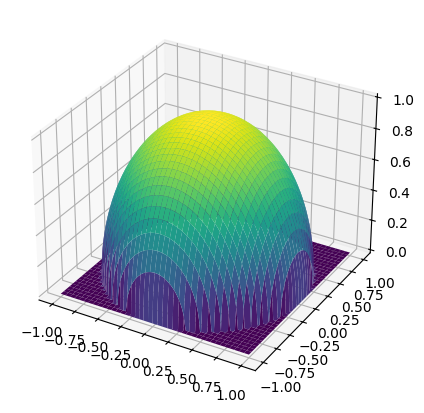

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
import sympy as sp
import math

N = 200
x = np.linspace(-1, 1, N+1)
y = np.linspace(-1, 1, N+1)

X,Y = np.meshgrid(x,y)
Z = np.zeros_like(X)

def f(x, y):
    r2 = x**2 + y**2
    if r2 < 1:
      return np.sqrt(1 - r2)
    else:
      return 0

for i in range(N):
  for j in range(N):
    Z[i,j] = f(x[i],y[j])

from matplotlib import cm
fig1 = plt.figure(figsize=(5,5))
ax1 = fig1.add_subplot(111, projection='3d')
ax1.plot_surface(X,Y,Z,cmap='viridis')

h = (2*1)/N
f(x[1], y[1])

h = (2*1)/N

integral = 0

for i in range(N):
    for j in range(N):
        f1 = f(x[i],   y[j])
        f2 = f(x[i+1], y[j])
        f3 = f(x[i],   y[j+1])
        f4 = f(x[i+1], y[j+1])

        integral += (h**2/4)*(f1 + f2 + f3 + f4)

print('Volumen estimado: ', float(integral))

In [2]:
# Calculo el área con Simpson :)

def g(x, y): #Defino la función de la esfera en cartesianas
    #El principal supuesto geométrico es que el área que voy a calcular está en por encima del plano x-y
    r2 = x**2 + y**2
    if r2 < 1:
        return 1/np.sqrt(1-r2) #También tengo que definir el dominio de la función ya que en cartesianas el denominador puede ser cero
    else:
        return 0

r = np.linspace(0, 1, N+1); hr = 1 / N #Tengo que definir los valores para r y para theta
theta = np.linspace(0, 2*np.pi, N+1); ht = (2*np.pi) / N

def h(r):
    return r / np.sqrt(1 - r*r) #Esta es la función que aparece en doble integral con dtheta y dr al hacer el cambio de coordenadas

#------------------------------------------------------------------------------------

integral = 0

Iy = np.zeros(N+1)

for i in range(N+1):
    s = g(x[i], y[0]) + g(x[i], y[N])

    for j in range(1, N, 2):
        s += 4 * g(x[i], y[j])

    for j in range(2, N-1, 2):
        s += 2 * g(x[i], y[j])

    Iy[i] = s * h / 3

    integral = Iy[0] + Iy[N]

for i in range(1, N, 2):
    integral += 4 * Iy[i]

for i in range(2, N-1, 2):
    integral += 2 * Iy[i]

integral *= h / 3
integral

np.float64(6.200577182173617)

In [5]:
N = 200
R = 1.

x = np.linspace(-R, R, N+1)
y = np.linspace(-R, R, N+1)

#Decidimos utilizar la misma definición de h que en la clase

h = (2*R) / N

X, Y = np.meshgrid(x, y)

#plt.scatter(X, Y)
#plt.show()

def funcion(x,y):
    if (x**2 + y**2 >= R**2):
        return 0.0
    else:
        return np.sqrt(R**2 - x**2 - y**2)

def funcionParaArea(x,y):
  if (x**2 + y**2 >= R**2):
        return 0.0
  else:
      return R / np.sqrt(R**2 - x**2 - y**2)

Z = np.zeros_like(X)

for i in range(N):
    for j in range(N):
        Z[i,j] = funcion(x[i], y[j])

area = 0

for i in range(N):
    for j in range(N):

        primeraParte = funcionParaArea(x[i], y[j])
        segundaParte = funcionParaArea(x[i+1], y[j])
        terceraParte = funcionParaArea(x[i], y[j+1])
        cuartaParte = funcionParaArea(x[i+1], y[j+1])

        deltaA = (h**2 / 4.0) * (primeraParte + segundaParte + terceraParte + cuartaParte)

        area += deltaA

print("Area superficial estimada:")
print(area)

Area superficial estimada:
6.181363856549002


In [6]:
2*np.pi #Área exacta

6.283185307179586

Con la misma cantidad de particiones el método de simpson se acerca más a el valor de área exacto